## **Problem Definition**


This project aims to predict Customer Churn in a telecom company.

Customer churn refers to customers who stop using a service.

The main objective is to build a machine learning model that can classify whether a customer will churn or not based on their behavior and account information.

### **Data Understanding**

This dataset contains information about telecom customers and whether they have churned (left the service or not).

Each row represents a customer and each column represents a feature describing their account, usage, and demographic information.

The target variable is Churn, which indicates whether the customer has left the company.

## Import Libraries

In [2]:
# Importing necessary libraries for data analysis and machine learning

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report, confusion_matrix

## Upload / Load Dataset

In [1]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [3]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Check Data

In [4]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


##Data Cleaning

In this step, we prepare the dataset for machine learning by handling missing values, fixing incorrect data types, and ensuring data consistency.

In [7]:
# Fix TotalCharges (string → numeric)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Remove missing values safely
df = df.dropna(subset=['TotalCharges', 'Churn'])

## Target Encoding

In [6]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

df['Churn'].value_counts()

,count
Churn,
0,5163
1,1869


## Encoding Features

In [9]:
df = pd.get_dummies(df, drop_first=True)
print(df.columns)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'customerID_0003-MKNFE', 'customerID_0004-TLHLJ',
       'customerID_0011-IGKFF', 'customerID_0013-EXCHZ',
       'customerID_0013-MHZWF',
       ...
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object', length=7062)


## Split Data

In [13]:
X = df.drop('Churn', axis=1)
y = df['Churn']

print("Missing in y:", y.isnull().sum())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Missing in y: 0


## Scaling

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Train Logistic Regression Model

In [14]:
model = LogisticRegression(max_iter=2000, class_weight='balanced')

model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=2000)

## Make Predictions

In [ ]:
y_pred = model.predict(X_test_scaled)

## Model Evaluation

In [17]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ROC-AUC: 0.8254215177226395


## Overfitting / Class imbalance

Handling class imbalance improved recall for churned customers.

In [18]:
# Logistic Regression with class balancing to handle imbalanced data
model = LogisticRegression(max_iter=2000, class_weight='balanced')

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

In [19]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[954  79]
 [224 150]]
              precision    recall  f1-score   support

           0       0.81      0.92      0.86      1033
           1       0.66      0.40      0.50       374

    accuracy                           0.78      1407
   macro avg       0.73      0.66      0.68      1407
weighted avg       0.77      0.78      0.77      1407



## Decision Tree

In [20]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)

tree_model.fit(X_train_scaled, y_train)
y_pred_tree = tree_model.predict(X_test_scaled)

## Random Forest

In [22]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

In [23]:
print("Logistic Regression:", classification_report(y_test, y_pred))
print("Decision Tree:", classification_report(y_test, y_pred_tree))
print("Random Forest:", classification_report(y_test, y_pred_rf))

Logistic Regression:               precision    recall  f1-score   support

           0       0.81      0.92      0.86      1033
           1       0.66      0.40      0.50       374

    accuracy                           0.78      1407
   macro avg       0.73      0.66      0.68      1407
weighted avg       0.77      0.78      0.77      1407

Decision Tree:               precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.59      0.58       374

    accuracy                           0.78      1407
   macro avg       0.71      0.72      0.71      1407
weighted avg       0.78      0.78      0.78      1407

Random Forest:               precision    recall  f1-score   support

           0       0.82      0.91      0.86      1033
           1       0.65      0.44      0.52       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.69      1407
weighted avg       0.77

Random Forest best model

## Overfitting Check

Model shows slight overfitting (train > test accuracy)

In [24]:
print("Train score:", rf_model.score(X_train_scaled, y_train))
print("Test score:", rf_model.score(X_test_scaled, y_test))

Train score: 1.0
Test score: 0.7874911158493249


## Feature Importance

Feature importance shows which variables have the most influence on the model’s predictions.

In this project, a Random Forest model was used to calculate feature importance scores.

The results indicate that features such as **tenure**, **MonthlyCharges**, and **Contract type** are among the most influential factors in predicting customer churn.

These insights help us understand the key drivers behind customer behavior and can be used for business decision-making and retention strategies.

                             Feature  Importance
3                       TotalCharges    0.102437
1                             tenure    0.095978
2                     MonthlyCharges    0.083280
7041     InternetService_Fiber optic    0.026298
7050                 TechSupport_Yes    0.021811
7056               Contract_Two year    0.021601
7059  PaymentMethod_Electronic check    0.021445
7044              OnlineSecurity_Yes    0.021355
7055               Contract_One year    0.017938
7057            PaperlessBilling_Yes    0.017083
7035                     gender_Male    0.015841
7036                     Partner_Yes    0.015289
7046                OnlineBackup_Yes    0.014478
0                      SeniorCitizen    0.014060
7037                  Dependents_Yes    0.013318


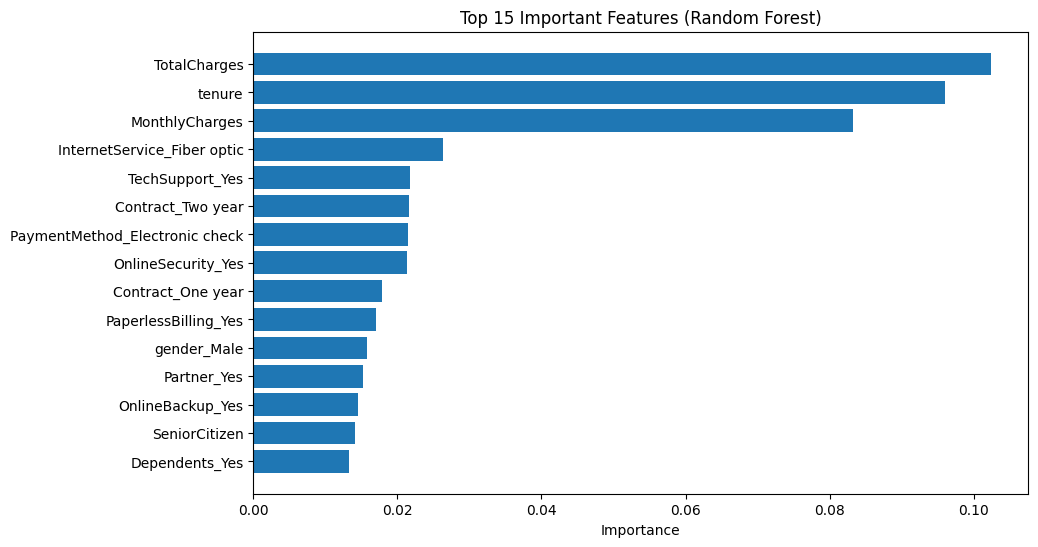

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
features = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

top_15 = feature_importance_df.head(15)

print(top_15)

plt.figure(figsize=(10,6))
plt.barh(top_15['Feature'][::-1], top_15['Importance'][::-1])
plt.title("Top 15 Important Features (Random Forest)")
plt.xlabel("Importance")
plt.show()

## PCA

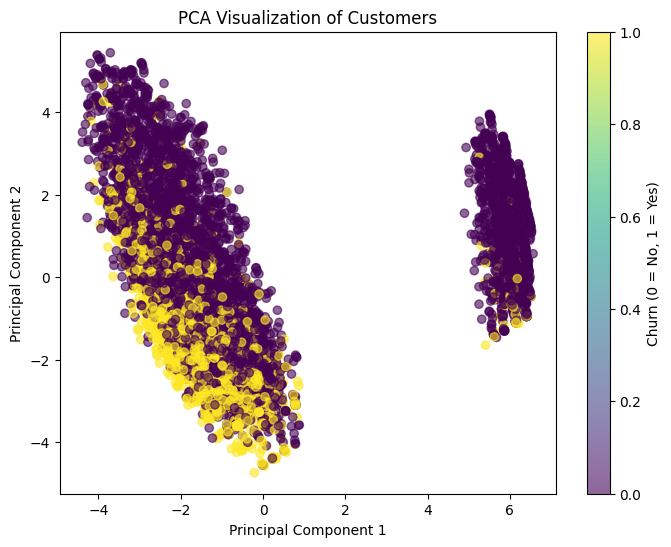

In [26]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Reduce to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_train, cmap='viridis', alpha=0.6)
plt.title("PCA Visualization of Customers")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Churn (0 = No, 1 = Yes)")
plt.show()

## 📉 PCA Visualization

Principal Component Analysis (PCA) was used to reduce the high-dimensional dataset into two dimensions for visualization purposes.

This helps to understand whether customers with similar churn behavior form separable patterns in the feature space.

Each point represents a customer, and the color indicates whether the customer churned or not.

## Clustering

In [33]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_train_scaled)

print(np.unique(clusters))
print(pd.Series(clusters).value_counts())

[0 1 2]
1    3843
2    1233
0     549
Name: count, dtype: int64


In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Separate features (only numeric-safe version)
X = df.drop(['Churn'], axis=1)

# 2. Scale data (important for KMeans)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Fit KMeans on FULL dataset
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# 4. Add clusters to dataframe
df['Cluster'] = clusters

# 5. Outputs
print("Cluster counts:")
print(df['Cluster'].value_counts())

print("\nCluster preview:")
print(df.groupby('Cluster').mean().head())

Cluster counts:
Cluster
1    3035
0    2477
2    1520
Name: count, dtype: int64

Cluster preview:
         SeniorCitizen     tenure  MonthlyCharges  TotalCharges     Churn  \
Cluster                                                                     
0             0.133629  52.765038       86.293379   4607.522124  0.138878   
1             0.250082  16.697199       69.152010   1196.771499  0.465239   
2             0.034211  30.667763       21.076283    665.220329  0.074342   

         customerID_0003-MKNFE  customerID_0004-TLHLJ  customerID_0011-IGKFF  \
Cluster                                                                        
0                     0.000000               0.000000               0.000000   
1                     0.000329               0.000329               0.000329   
2                     0.000000               0.000000               0.000000   

         customerID_0013-EXCHZ  customerID_0013-MHZWF  ...  \
Cluster                                              

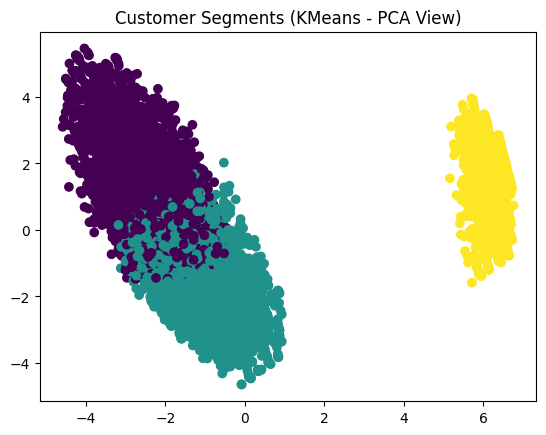

In [38]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis')
plt.title("Customer Segments (KMeans - PCA View)")
plt.show()

In [39]:
# Ensure no missing mapping
df['Segment'] = df['Cluster'].map({
    0: 'Loyal Customers',
    1: 'High Risk',
    2: 'Low Usage'
}).fillna('Unknown')

# Output
print(df[['Cluster', 'Segment']].head())

print("\nSegment counts:")
print(df['Segment'].value_counts())

   Cluster          Segment
0        1        High Risk
1        0  Loyal Customers
2        1        High Risk
3        0  Loyal Customers
4        1        High Risk

Segment counts:
Segment
High Risk          3035
Loyal Customers    2477
Low Usage          1520
Name: count, dtype: int64


In [40]:
df.groupby('Segment').mean(numeric_only=True)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Cluster
Segment,,,,,,,,,,,,,,,,,,,,,
High Risk,0.250082,16.697199,69.152010,1196.771499,0.465239,0.000329,0.000329,0.000329,0.000329,0.000000,...,0.309390,0.0,0.307084,0.051071,0.018781,0.690610,0.118287,0.547611,0.192422,1.0
Low Usage,0.034211,30.667763,21.076283,665.220329,0.074342,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.0,0.000000,0.238816,0.416447,0.292763,0.217763,0.080263,0.483553,2.0
Loyal Customers,0.133629,52.765038,86.293379,4607.522124,0.138878,0.000000,0.000000,0.000000,0.000000,0.000404,...,0.712152,0.0,0.726282,0.385143,0.401696,0.656843,0.335486,0.234558,0.115059,0.0


This plot shows the distribution of customers across different clusters, helping us understand the size of each customer segment.

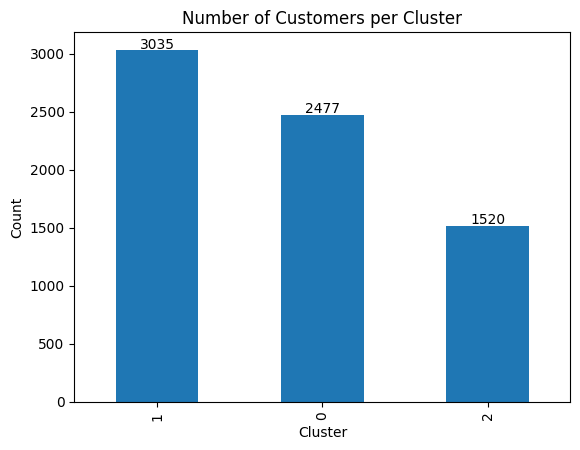

In [41]:
ax = df['Cluster'].value_counts().plot(kind='bar')

plt.title("Number of Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")

for i, v in enumerate(df['Cluster'].value_counts()):
    ax.text(i, v + 10, str(v), ha='center')

plt.show()

This boxplot shows the distribution of monthly charges across different customer segments.

It helps identify whether certain customer groups are associated with higher subscription costs, which may influence churn behavior.

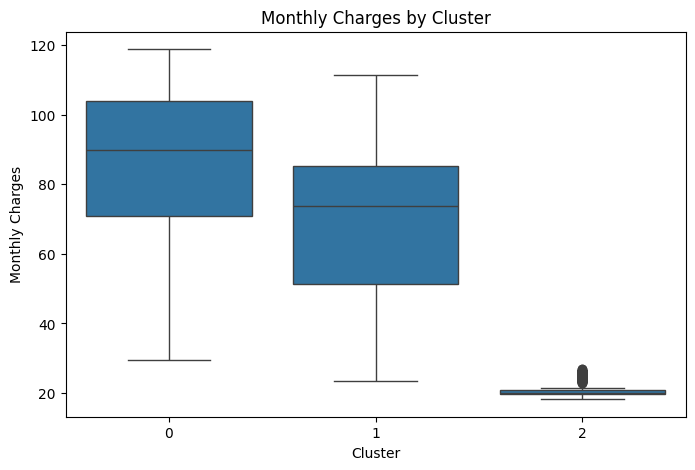

In [42]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Cluster', y='MonthlyCharges', data=df)
plt.title("Monthly Charges by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Monthly Charges")
plt.show()

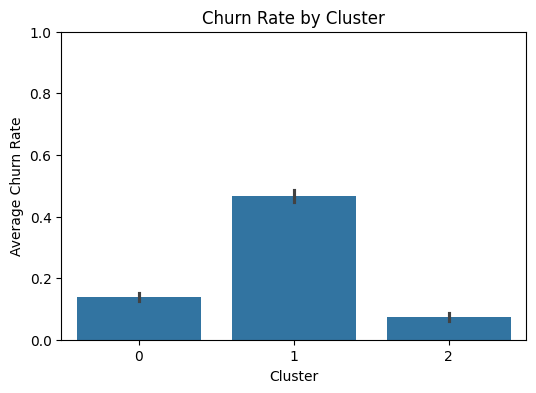

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.barplot(x='Cluster', y='Churn', data=df)
plt.title("Churn Rate by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Churn Rate")
plt.ylim(0,1)
plt.show()

### Final Insights

## 🔍 Key Insights

From the analysis and modeling of customer churn, the following insights were identified:

- Customers with shorter tenure are significantly more likely to churn.
- Higher monthly charges are associated with a higher probability of churn.
- Customers on month-to-month contracts show the highest churn rate compared to long-term contracts.
- Logistic Regression and Random Forest models both showed reasonable performance, with Random Forest slightly outperforming others.
- Class imbalance affected model performance, especially recall for churned customers, which improved after applying class weighting.

### Cluster-Based Business Insights

## 📊 Customer Segmentation Insights

Using K-Means clustering, customers were grouped into three segments:

- **High Risk Customers**: Low tenure, higher churn rate, more likely to leave the service.
- **Loyal Customers**: High tenure, stable usage, low churn probability.
- **Low Usage Customers**: Lower engagement and lower service usage.

These segments can be used for targeted retention strategies.

### Final Conclusion

## 🎯 Conclusion

This project successfully developed a machine learning pipeline to predict customer churn in a telecom dataset.

Key steps included data preprocessing, exploratory data analysis, supervised learning models, and unsupervised clustering for customer segmentation.

The results show that customer tenure, contract type, and monthly charges are the most important factors influencing churn.

This analysis can help businesses design better retention strategies by identifying at-risk customers early and targeting them with appropriate interventions.